Customer Churn Prediction – Exploratory Data Analysis

The objective of this notebook is to explore the cleaned Telco Customer Churn dataset to understand the characteristics of customers who leave the company. Exploratory Data Analysis (EDA) identifies important patterns, relationships, and trends that will guide feature selection for predictive machine learning models.

2. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

3. Load Clean Dataset

In [2]:
df = pd.read_csv("Telco_Churn_Clean.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AverageMonthlySpend
0,7590-VHVEG,Female,No,Yes,No,1,No,No,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.850000
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,55.573529
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,54.075000
3,7795-CFOCW,Male,No,No,No,45,No,No,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.905556
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,75.825000


In [3]:
df.shape

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customerID           7032 non-null   str    
 1   gender               7032 non-null   str    
 2   SeniorCitizen        7032 non-null   str    
 3   Partner              7032 non-null   str    
 4   Dependents           7032 non-null   str    
 5   tenure               7032 non-null   int64  
 6   PhoneService         7032 non-null   str    
 7   MultipleLines        7032 non-null   str    
 8   InternetService      7032 non-null   str    
 9   OnlineSecurity       7032 non-null   str    
 10  OnlineBackup         7032 non-null   str    
 11  DeviceProtection     7032 non-null   str    
 12  TechSupport          7032 non-null   str    
 13  StreamingTV          7032 non-null   str    
 14  StreamingMovies      7032 non-null   str    
 15  Contract             7032 non-null   str    
 16 

4. Business Understanding and Dataset Overview

4.1 Business Problem



Customer churn is one of the most important business challenges for subscription-based companies. Losing customers results in reduced recurring revenue and increased marketing costs to acquire new customers. By identifying customers who are likely to cancel their service, businesses can proactively intervene with retention strategies such as discounts, personalized offers, or improved customer support.

The goal of this project is to explore customer characteristics associated with churn and identify the most influential variables before building a machine learning classification model.

4.2 Dataset Summary

In [4]:
print("Dataset Shape:", df.shape)

print("\nNumber of Customers:", df.shape[0])
print("Number of Features:", df.shape[1]-1)

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (7032, 22)

Number of Customers: 7032
Number of Features: 21

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'AverageMonthlySpend']


The cleaned dataset contains one record for each customer. Each feature describes demographic information, account details, subscribed services, billing information, or the customer's churn status.

4.3 Identify Feature Types

In [5]:
numerical_columns = df.select_dtypes(include=["int64","float64"]).columns.tolist()

categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features")
print(numerical_columns)

print("\nCategorical Features")
print(categorical_columns)

Numerical Features
['tenure', 'MonthlyCharges', 'TotalCharges', 'AverageMonthlySpend']

Categorical Features
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


C:\Users\kedha\AppData\Local\Temp\ipykernel_20128\3042638779.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()


In [6]:
print(f"Total Numerical Features: {len(numerical_columns)}")
print(f"Total Categorical Features: {len(categorical_columns)}")

Total Numerical Features: 4
Total Categorical Features: 18


The dataset contains both numerical and categorical variables. Numerical variables will primarily be analyzed using histograms, boxplots, and correlation analysis, while categorical variables will be analyzed using count plots, contingency tables, and Chi-Square tests.

4.4 Business Workflow

In [7]:
workflow = [
    "Customer Uses Services",
    "Customer Information Collected",
    "Machine Learning Model Predicts Churn Risk",
    "High-Risk Customers Flagged",
    "Retention Team Contacts Customer",
    "Reduced Customer Churn"
]

print("Business Workflow\n")

for step in workflow:
    print(step)

    if step != workflow[-1]:
        print("      ↓")

Business Workflow

Customer Uses Services
      ↓
Customer Information Collected
      ↓
Machine Learning Model Predicts Churn Risk
      ↓
High-Risk Customers Flagged
      ↓
Retention Team Contacts Customer
      ↓
Reduced Customer Churn


The predictive model fits into the company's customer retention workflow by identifying customers who are most likely to cancel their service. Rather than contacting every customer, the company can focus its retention efforts on those with the highest predicted risk, improving efficiency and reducing customer turnover.

4.5 Machine Learning Problem Type

In [8]:
print("Target Variable:", "Churn")
print("Unique Classes:", df["Churn"].unique())
print("\nClass Distribution:")
print(df["Churn"].value_counts())

Target Variable: Churn
Unique Classes: <StringArray>
['No', 'Yes']
Length: 2, dtype: str

Class Distribution:
Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [9]:
print("\nPercentage Distribution")

(df["Churn"].value_counts(normalize=True)*100).round(2)


Percentage Distribution


Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64

The target variable contains two possible outcomes: Yes and No. Since the objective is to predict one of two classes, this is a binary classification problem. Suitable machine learning algorithms include Logistic Regression, Decision Trees, Random Forest, Gradient Boosting, and XGBoost.

4.6 Potential End Users

In [11]:
end_users = {
    "Retention Team":
        "Contact high-risk customers before they leave",

    "Marketing Team":
        "Create targeted retention campaigns",

    "Customer Service":
        "Prioritize customers with high churn probability",

    "Management":
        "Monitor churn trends through dashboards"
}

for department, purpose in end_users.items():
    print(f"{department}:")
    print(f"   {purpose}\n")

Retention Team:
   Contact high-risk customers before they leave

Marketing Team:
   Create targeted retention campaigns

Customer Service:
   Prioritize customers with high churn probability

Management:
   Monitor churn trends through dashboards



Different departments can use the model predictions to improve customer retention. Instead of relying on intuition, decision-makers can prioritize customers based on predicted churn probability.

4.7 Success Metrics

In [12]:
ml_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

business_metrics = [
    "Reduction in churn rate",
    "Customer retention rate",
    "Revenue retained",
    "Customer Lifetime Value (CLV)",
    "Retention campaign effectiveness"
]

print("Machine Learning Evaluation Metrics")

for metric in ml_metrics:
    print("-", metric)

print("\nBusiness Evaluation Metrics")

for metric in business_metrics:
    print("-", metric)

Machine Learning Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

Business Evaluation Metrics
- Reduction in churn rate
- Customer retention rate
- Revenue retained
- Customer Lifetime Value (CLV)
- Retention campaign effectiveness


The effectiveness of the predictive model will be evaluated using both machine learning performance metrics and business outcomes. While metrics such as Precision, Recall, F1-Score, and ROC-AUC assess predictive performance, the ultimate measure of success is the model's ability to reduce customer churn and improve customer retention through targeted intervention strategies.

5. Target Variable Analysis

<Axes: xlabel='Churn', ylabel='count'>

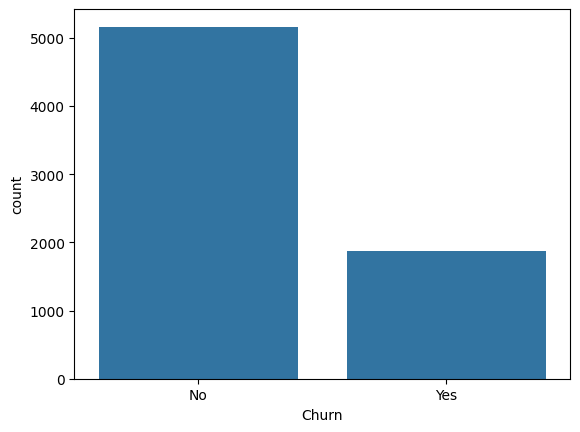

In [13]:
sns.countplot(data=df,x="Churn")

6. Numerical Feature Analysis

In [14]:
numeric_cols=[
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AverageMonthlySpend"
]

<Axes: ylabel='Count'>

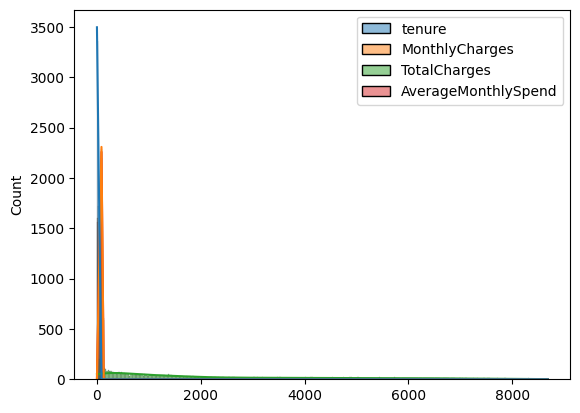

In [16]:
sns.histplot(df[numeric_cols],kde=True)

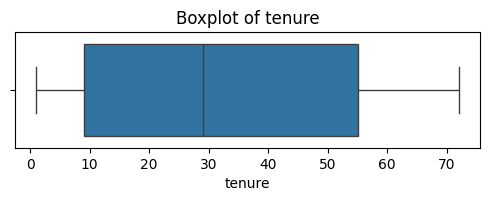

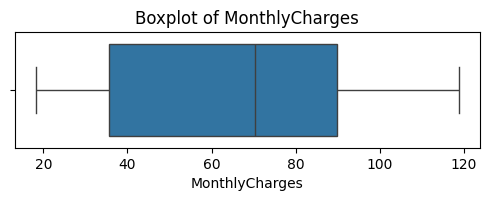

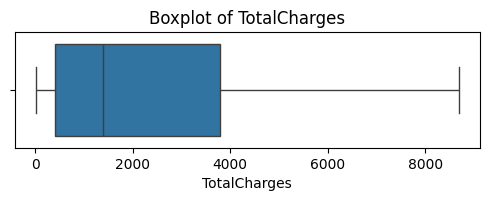

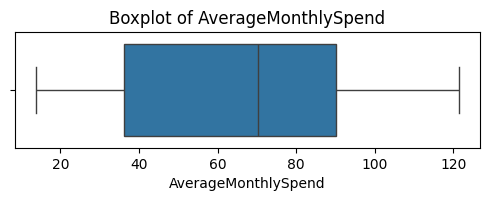

In [19]:
for col in numeric_cols:
    plt.figure(figsize=(6, 1.5))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

7. Categorical Feature Analysis

([0, 1, 2],
 [Text(0, 0, 'Month-to-month'),
  Text(1, 0, 'One year'),
  Text(2, 0, 'Two year')])

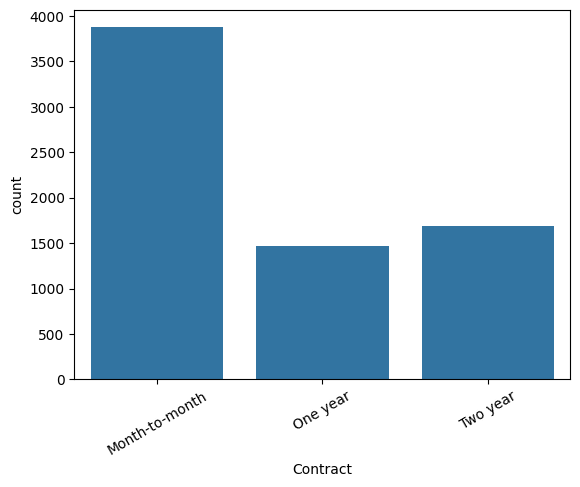

In [20]:
sns.countplot(data=df,x="Contract")
plt.xticks(rotation=30)

8. Relationship Between Features and Churn

<Axes: xlabel='Contract', ylabel='count'>

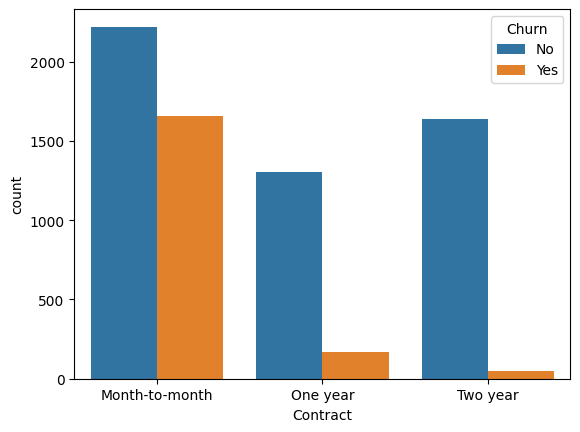

In [21]:
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

9. Numerical Features vs Churn

<Axes: xlabel='Churn', ylabel='tenure'>

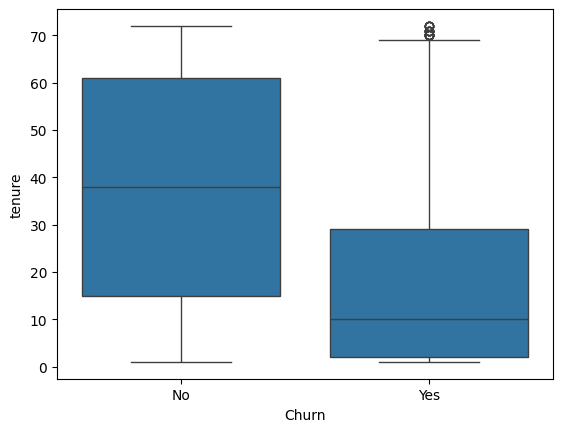

In [22]:
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

10. Correlation Analysis

<Axes: >

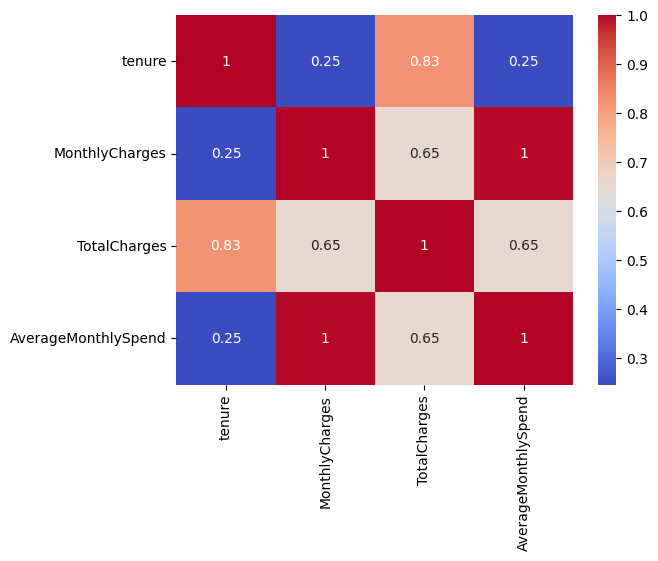

In [23]:
corr=df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

11. Pearson Correlation

In [26]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["tenure"], df["MonthlyCharges"])

print("Pearson Correlation:", corr)
print("P-value:", p_value)

Pearson Correlation: 0.2468617666408935
P-value: 3.989821323221685e-98


In [27]:
pearsonr(df["tenure"],df["MonthlyCharges"])

PearsonRResult(statistic=np.float64(0.2468617666408935), pvalue=np.float64(3.989821323221685e-98))

In [28]:
pearsonr(df["MonthlyCharges"],df["TotalCharges"])

pearsonr(df["tenure"],df["TotalCharges"])

pearsonr(df["AverageMonthlySpend"],df["MonthlyCharges"])

PearsonRResult(statistic=np.float64(0.9962373123907752), pvalue=np.float64(0.0))

12. Chi-Square Tests

In [30]:
from scipy.stats import chi2_contingency

categorical_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity"
]

for feature in categorical_features:
    print("="*60)
    print(f"Chi-Square Test: {feature}")

    table = pd.crosstab(df[feature], df["Churn"])

    chi2, p, dof, expected = chi2_contingency(table)

    print(f"Chi-Square Statistic: {chi2:.2f}")
    print(f"Degrees of Freedom: {dof}")
    print(f"P-value: {p:.6f}")

    if p < 0.05:
        print("Result: There is a statistically significant relationship between "
              f"{feature} and Churn.")
    else:
        print("Result: There is no statistically significant relationship between "
              f"{feature} and Churn.")

    print()

Chi-Square Test: Contract
Chi-Square Statistic: 1179.55
Degrees of Freedom: 2
P-value: 0.000000
Result: There is a statistically significant relationship between Contract and Churn.

Chi-Square Test: InternetService
Chi-Square Statistic: 728.70
Degrees of Freedom: 2
P-value: 0.000000
Result: There is a statistically significant relationship between InternetService and Churn.

Chi-Square Test: PaymentMethod
Chi-Square Statistic: 645.43
Degrees of Freedom: 3
P-value: 0.000000
Result: There is a statistically significant relationship between PaymentMethod and Churn.

Chi-Square Test: TechSupport
Chi-Square Statistic: 824.93
Degrees of Freedom: 2
P-value: 0.000000
Result: There is a statistically significant relationship between TechSupport and Churn.

Chi-Square Test: OnlineSecurity
Chi-Square Statistic: 846.68
Degrees of Freedom: 2
P-value: 0.000000
Result: There is a statistically significant relationship between OnlineSecurity and Churn.



13. Pairplots

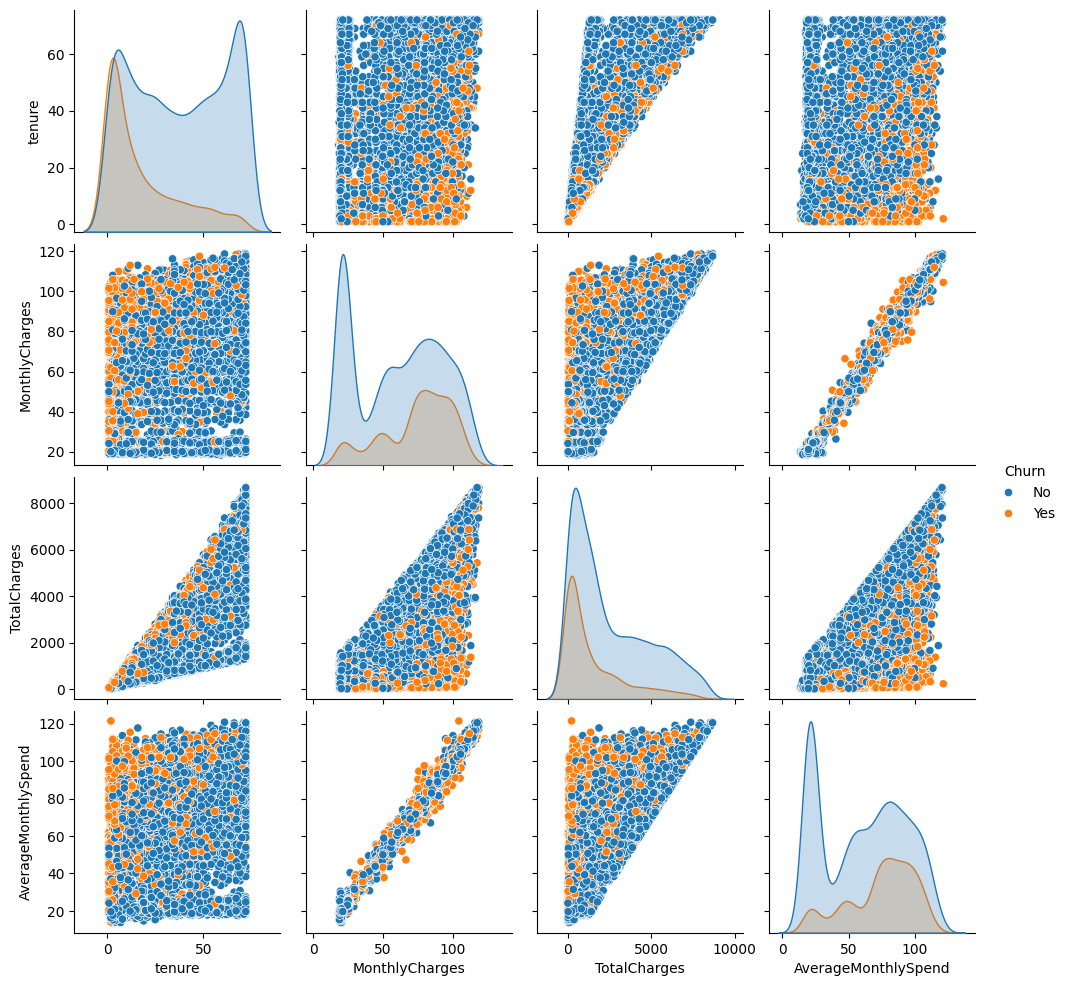

In [31]:
sns.pairplot(
    df[numeric_cols+["Churn"]],
    hue="Churn"
)

14. Feature Importance Discussion

| Feature         | Evidence                               |
| --------------- | -------------------------------------- |
| Contract        | Strong separation between churn groups |
| Tenure          | Long-term customers churn less         |
| TechSupport     | Customers without support churn more   |
| OnlineSecurity  | Associated with lower churn            |
| MonthlyCharges  | Higher charges linked to churn         |
| InternetService | Fiber customers churn more             |
| PaymentMethod   | Electronic check customers churn more  |


15. Business Integration

Customer Database

↓

Daily ML Model

↓

Generate Churn Risk Score

↓

Dashboard

↓

Retention Team

↓

Customer Outreach

16. Evaluation Plan

Model metrics:

Accuracy
Precision
Recall
F1-score
ROC-AUC

Business metrics:

Monthly churn reduction
Customer retention rate
Revenue retained
Customer lifetime value (CLV)
Cost savings

17. Final Conclusions

The analysis identified several key factors influencing customer churn. Contract type, tenure, and monthly charges showed strong relationships with churn, with month-to-month customers, newer customers, and customers with higher charges being more likely to leave.

Additional services such as technical support and online security appeared to reduce churn, suggesting that customer engagement and added value play an important role in retention. These findings will guide feature selection and model development for the predictive modeling phase.